In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# LOAD DATASETS

fund_master = pd.read_csv(
    "data/processed/01_fund_master_clean.csv"
)

nav = pd.read_csv(
    "data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "data/processed/07_scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "data/processed/08_investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    "data/processed/09_portfolio_holdings_clean.csv"
)

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Scheme Performance:", performance.shape)
print("Investor Transactions:", transactions.shape)
print("Portfolio Holdings:", holdings.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

print("Date Conversion Completed!")

Date Conversion Completed!


# Task 1 – Historical VaR (95%) and CVaR

In [5]:
# COMPUTE DAILY RETURNS

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [6]:
# HISTORICAL VAR & CVAR
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append(
        [
            code,
            var95,
            cvar95
        ]
    )

var_cvar = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

print(var_cvar.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [7]:
# ADD SCHEME NAME

var_cvar = var_cvar.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"
)

var_cvar = var_cvar[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95",
        "CVaR_95"
    ]
]

var_cvar.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [8]:
var_cvar.to_csv(

    "reports/var_cvar_report.csv",

    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


# Task 2 – Rolling 90-Day Sharpe Ratio

In [9]:
# SELECT TOP 5 FUNDS BASED ON 5-YEAR RETURN

top5 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5[["scheme_name", "return_5yr_pct"]])

                                       scheme_name  return_5yr_pct
29          ABSL Small Cap Fund - Regular - Growth           23.80
27          Axis Small Cap Fund - Regular - Growth           22.62
17  Nippon India Small Cap Fund - Regular - Growth           21.88
3        SBI Small Cap Fund - Direct Plan - Growth           21.82
2       SBI Small Cap Fund - Regular Plan - Growth           20.67


In [10]:
# CALCULATE ROLLING 90-DAY SHARPE RATIO

rolling_sharpe = {}

for code in top5_codes:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    df = df.sort_values("date")

    returns = df["daily_return"]

    sharpe = (
        returns.rolling(window=90).mean()
        /
        returns.rolling(window=90).std()
    ) * np.sqrt(252)

    rolling_sharpe[code] = pd.DataFrame({
        "date": df["date"],
        "rolling_sharpe": sharpe
    })

print("Rolling Sharpe Calculated Successfully!")

Rolling Sharpe Calculated Successfully!


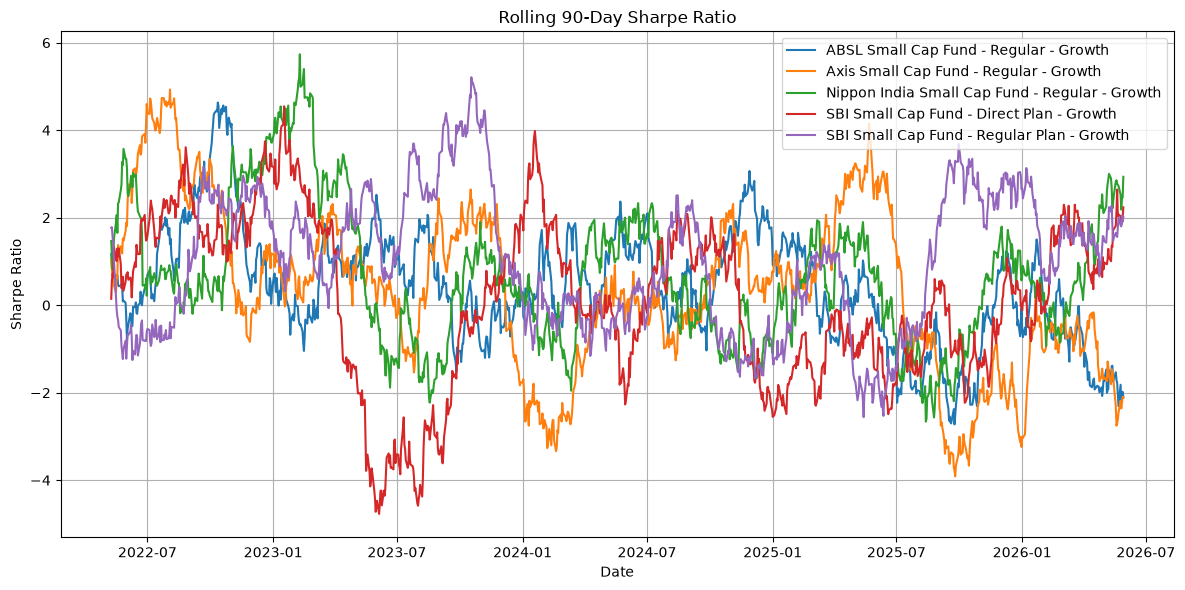

Chart saved successfully!


In [11]:
# PLOT ROLLING SHARPE RATIO

plt.figure(figsize=(12,6))

for code in top5_codes:

    scheme = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    plt.plot(
        rolling_sharpe[code]["date"],
        rolling_sharpe[code]["rolling_sharpe"],
        label=scheme
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

print("Chart saved successfully!")

# Task 3: Investor Cohort Analysis

In [12]:
# FIRST TRANSACTION YEAR OF EACH INVESTOR

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"].dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [13]:
# MERGE COHORT YEAR

transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [14]:
# COHORT ANALYSIS

cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [15]:
# TOP FUND PREFERENCE

top_fund = (
    transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

top_fund = top_fund[
    ["cohort_year", "scheme_name"]
]

top_fund.rename(
    columns={
        "scheme_name": "top_fund"
    },
    inplace=True
)

top_fund

,cohort_year,top_fund
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,SBI Small Cap Fund - Direct Plan - Growth


In [16]:
# FINAL COHORT REPORT

cohort_report = cohort_summary.merge(
    top_fund,
    on="cohort_year"
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [17]:
# SAVE REPORT

cohort_report.to_csv(
    "reports/investor_cohort_report.csv",
    index=False
)

print("Investor Cohort Report Saved Successfully!")

Investor Cohort Report Saved Successfully!


# Task 4: SIP Continuity Analysis

In [18]:
# FILTER SIP TRANSACTIONS

sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

print("Total SIP Transactions:", len(sip_txn))

Total SIP Transactions: 19716


In [19]:
# INVESTORS WITH 6+ SIPs

sip_counts = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]

sip_txn = sip_txn.merge(
    eligible[["investor_id"]],
    on="investor_id"
)

print("Eligible Investors:", sip_txn["investor_id"].nunique())

Eligible Investors: 1362


In [20]:
# GAP BETWEEN SIP DATES

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
0,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
1,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
2,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
3,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
4,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [21]:
# AVERAGE GAP

continuity = (
    sip_txn.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        sip_transactions=("gap_days", "count")
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days,sip_transactions
0,INV000004,85.400000,5
1,INV000008,70.400000,5
2,INV000010,64.800000,5
3,INV000011,40.166667,6
4,INV000012,57.000000,7


In [22]:
# FLAG AT-RISK INVESTORS

continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

continuity.head()

,investor_id,avg_gap_days,sip_transactions,status
0,INV000004,85.400000,5,At Risk
1,INV000008,70.400000,5,At Risk
2,INV000010,64.800000,5,At Risk
3,INV000011,40.166667,6,At Risk
4,INV000012,57.000000,7,At Risk


In [23]:
# SAVE REPORT

continuity.to_csv(
    "reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved Successfully!")

SIP Continuity Report Saved Successfully!


# Task 5: Simple Fund Recommender

In [24]:
from recommender import print_recommendation

In [25]:
print_recommendation("Low")


 FUND RECOMMENDATION
Risk Appetite : Low

                             scheme_name               fund_house category risk_grade  sharpe_ratio  return_3yr_pct
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF   Liquid        Low          7.68            7.68
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF   Liquid        Low          6.18            6.18
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF   Liquid        Low          5.14            5.14


In [26]:
print_recommendation("Moderate")


 FUND RECOMMENDATION
Risk Appetite : Moderate

                                  scheme_name          fund_house  category risk_grade  sharpe_ratio  return_3yr_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund Large Cap   Moderate          1.06           14.84
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF Large Cap   Moderate          1.06           14.81
    ICICI Pru Bluechip Fund - Direct - Growth ICICI Prudential MF Large Cap   Moderate          1.03           14.41


In [27]:
print_recommendation("High")


 FUND RECOMMENDATION
Risk Appetite : High

                                  scheme_name          fund_house category risk_grade  sharpe_ratio  return_3yr_pct
Kotak Emerging Equity Fund - Regular - Growth   Kotak Mahindra MF  Mid Cap       High          0.96           18.23
     ICICI Pru Midcap Fund - Regular - Growth ICICI Prudential MF  Mid Cap       High          0.95           18.08
           DSP Midcap Fund - Regular - Growth     DSP Mutual Fund  Mid Cap       High          0.90           17.16


# Task 6: Sector HHI Concentration

In [28]:
# SECTOR HHI CONCENTRATION

hhi = holdings.copy()

hhi["weight"] = hhi["weight_pct"] / 100

hhi["weight_sq"] = hhi["weight"] ** 2

# Compute HHI for each fund
hhi = (
    hhi.groupby("amfi_code")
    .agg(
        HHI=("weight_sq", "sum")
    )
    .reset_index()
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [29]:
# =====================================================
# ADD SCHEME NAME
# ========================================= ============

hhi = hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi = hhi[
    [
        "amfi_code",
        "scheme_name",
        "HHI"
    ]
]

hhi.head()

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.139534
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.129332
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709


In [30]:
# =====================================================
# RANK HHI
# =====================================================

hhi = hhi.sort_values(
    by="HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
23,120841,Kotak Bluechip Fund - Regular - Growth,0.149680


In [31]:
# =====================================================
# SAVE REPORT
# =====================================================

hhi.to_csv(
    "reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI Report Saved Successfully!")

Sector HHI Report Saved Successfully!


# Task 7: Advanced Insights

### Insight 1 – Historical VaR & CVaR

The Historical VaR (95%) and CVaR analysis identified the funds with the highest downside risk. Funds with more negative VaR and CVaR values experienced larger potential losses during adverse market conditions, indicating higher investment risk.

### Insight 2 – Rolling Sharpe Ratio

The 90-day Rolling Sharpe Ratio showed how the risk-adjusted performance of the selected funds changed over time. Funds with consistently higher Sharpe Ratios demonstrated better returns for the level of risk taken.

### Insight 3 – Investor Cohort Analysis

Investor cohort analysis revealed that the 2024 investor cohort contributed the highest total investment volume, while different cohorts showed varying average SIP investment amounts and fund preferences.

### Insight 4 – SIP Continuity Analysis

The SIP continuity analysis identified investors maintaining regular monthly SIP investments and flagged investors with an average transaction gap greater than 35 days as "At Risk", enabling proactive engagement strategies.

### Insight 5 – Sector HHI Concentration

The Herfindahl–Hirschman Index (HHI) measured portfolio concentration across equity funds. Higher HHI values indicated concentrated portfolios with greater exposure to fewer sectors, whereas lower HHI values represented better diversification.
